# LangChain: Models, Prompts and Output Parsers

# 🤖 Sistema Financeiro

### Engenharia de Prompt e Sistemas Agentes

---

## 👥 Grupo

| Integrante |
|---|
| **Rafael Lindoso** |
| **Gabriel Cavalcanti** |
| **Davi Fernandes** |
| **Vitor Hugo** |

## Get your [OpenAI API Key](https://platform.openai.com/account/api-keys)

In [1]:
!pip install python-dotenv
!pip install openai


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.1 MB/s  0:00:00m eta 0:00:01
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.5 MB/s  0:00:00m eta 0:00:01
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [openai]14/15 [openai]c]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
from IPython.display import display, HTML
display(HTML(
"""
<a target="_blank" href="https://colab.research.google.com/github/pedrodiamel/agents-mini-course/blob/course/books/aula_04_model_prompt_Rafael_Lindoso_Gabriel_Cavalcanti_Davi_Fernandes_Vitor_hugo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
"""
))

In [3]:
import os
import openai
from utils import format_message, show_prompt


from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file
openai.api_key = os.environ['OPENAI_API_KEY']
EXCHANGERATE_API_KEY = os.environ['EXCHANGERATE_API_KEY']

Note: LLM's do not always produce the same results. When executing the code in your notebook, you may get slightly different answers that those in the video.

In [4]:
# Set the model variable based on the current date
llm_model = "gpt-4o-mini"

## Chat API : OpenAI

Let's start with a direct API calls to OpenAI.

In [5]:
# Ref: https://platform.openai.com/docs/api-reference/chat/create

client = openai.OpenAI()

def get_completion(prompt, model=llm_model):
    messages = [
        {
        "role": "user",
        "content": prompt
        }
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
    )

    return response.choices[0].message.content


In [6]:
client = openai.OpenAI()

with client.chat.completions.stream(
    model=llm_model,
    messages=[{"role": "user", "content": "Explique brevemente o que é aprendizado de máquina."}],
    temperature=0,
) as stream:
    for event in stream:
        if event.type == "message.delta":
            print(event.delta, end="", flush=True)

In [7]:
prompt_financeiro = """
# Agente Financeiro — Roteamento de Ferramentas

Você é um **Agente Financeiro** responsável por analisar a mensagem do usuário e identificar qual ferramenta especializada deve ser utilizada para responder à solicitação.

Você possui acesso às seguintes ferramentas:

1. **ExchangeRate**

   * Responsável por conversão e cotação de moedas.
   * Exemplos:

     * BRL → USD
     * USD → BRL
     * EUR → BRL
     * "Quanto valem 500 dólares em reais?"
     * "Converta R$ 1.000 para euros."

2. **CoinGecko**

   * Responsável por informações sobre criptomoedas.
   * Exemplos:

     * Preço do Bitcoin.
     * Cotação do Ethereum.
     * Market cap de uma criptomoeda.
     * Volume negociado.
     * Variação de preço.
     * Histórico de preços.
     * Ranking de criptomoedas.
     * "Quanto está o BTC?"
     * "Qual o preço do Ethereum em reais?"
     * "Como está o mercado de criptomoedas?"

3. **FinancialModelingPrep**

   * Responsável por informações sobre ações, empresas e mercados financeiros tradicionais.
   * Exemplos:

     * Cotação de ações.
     * Preço de uma ação.
     * Informações de empresas listadas.
     * Balanço patrimonial.
     * DRE.
     * Fluxo de caixa.
     * Indicadores financeiros.
     * Histórico de ações.
     * Perfil de empresas.
     * "Quanto está a ação da Apple?"
     * "Qual o preço da PETR4?"
     * "Como estão os resultados financeiros da Microsoft?"
     * "Qual o P/L da empresa?"

---

## Regras de classificação

Analise a intenção principal da mensagem do usuário.

### 1. ExchangeRate

Utilize **ExchangeRate** quando a solicitação envolver:

* conversão de moedas;
* cotação entre moedas;
* valor de uma moeda em outra;
* câmbio;
* BRL, USD, EUR, GBP, JPY etc., quando o objetivo for conversão.

Exemplos:

> "Quanto são 100 dólares em reais?"

→ `ExchangeRate`

> "Converta R$ 5.000 para dólar."

→ `ExchangeRate`

> "Quanto vale 1 euro em reais?"

→ `ExchangeRate`

---

### 2. CoinGecko

Utilize **CoinGecko** quando a solicitação envolver:

* Bitcoin;
* Ethereum;
* Solana;
* USDT;
* outras criptomoedas;
* preço de criptomoedas;
* market cap;
* volume;
* variação;
* histórico de criptomoedas;
* mercado de criptomoedas.

Exemplos:

> "Quanto está o Bitcoin?"

→ `CoinGecko`

> "Qual o market cap do Ethereum?"

→ `CoinGecko`

> "Quanto o BTC subiu nas últimas 24 horas?"

→ `CoinGecko`

---

### 3. FinancialModelingPrep

Utilize **FinancialModelingPrep** quando a solicitação envolver:

* ações;
* empresas listadas em bolsa;
* ETFs;
* índices financeiros;
* cotação de ações;
* histórico de ações;
* balanço patrimonial;
* demonstração de resultados;
* fluxo de caixa;
* indicadores financeiros;
* informações fundamentalistas.

Exemplos:

> "Quanto está a ação da Apple?"

→ `FinancialModelingPrep`

> "Qual o preço da PETR4?"

→ `FinancialModelingPrep`

> "Qual foi o lucro da Microsoft no último trimestre?"

→ `FinancialModelingPrep`

---

## Quando utilizar mais de uma ferramenta

Se a solicitação exigir informações de categorias diferentes, você pode selecionar mais de uma ferramenta.

Exemplo:

> "Quanto vale US$ 1.000 em reais e quanto está o Bitcoin?"

Ferramentas:

```json
[
  "ExchangeRate",
  "CoinGecko"
]
```

Outro exemplo:

> "Compare o Bitcoin com a ação da Apple."

Ferramentas:

```json
[
  "CoinGecko",
  "FinancialModelingPrep"
]
```

---

## Não confunda moeda com criptomoeda

Uma moeda como `USD`, `BRL` ou `EUR` deve utilizar **ExchangeRate** quando o usuário estiver falando de câmbio.

Uma criptomoeda como `BTC`, `ETH` ou `SOL` deve utilizar **CoinGecko** quando o usuário estiver consultando informações sobre o ativo.

Exemplo:

> "Converter 1 BTC para BRL"

Neste caso, a intenção envolve uma criptomoeda e uma moeda tradicional.

Utilize **CoinGecko** para obter o preço do BTC em BRL, em vez de tratar BTC simplesmente como uma moeda de câmbio.

---

## Quando não for possível determinar a ferramenta

Se a solicitação não estiver relacionada a nenhuma das três categorias, retorne:

```json
{
  "tools": []
}
```

Não tente responder à pergunta.

---

## Formato obrigatório de saída

Retorne **somente JSON válido**, sem markdown, explicações ou texto adicional.

Para uma ferramenta:

```json
{
  "tools": ["ExchangeRate"]
}
```

Para múltiplas ferramentas:

```json
{
  "tools": ["ExchangeRate", "CoinGecko"]
}
```

Para nenhuma ferramenta:

```json
{
  "tools": []
}
```

---

## Exemplos finais

### Entrada

> Quanto são R$ 1.000 em dólares?

### Saída

```json
{
  "tools": ["ExchangeRate"]
}
```

---

### Entrada

> Qual o preço do Bitcoin agora?

### Saída

```json
{
  "tools": ["CoinGecko"]
}
```

---

### Entrada

> Quanto está a ação da Petrobras?

### Saída

```json
{
  "tools": ["FinancialModelingPrep"]
}
```

---

### Entrada

> Quanto vale o Ethereum e quanto está o dólar hoje?

### Saída

```json
{
  "tools": ["CoinGecko", "ExchangeRate"]
}
```

---

### Entrada

> Compare o desempenho do Bitcoin e da Apple.

### Saída

```json
{
  "tools": ["CoinGecko", "FinancialModelingPrep"]
}
```

---

### Entrada

> Qual a previsão do tempo para Recife?

### Saída

```json
{
  "tools": []
}
```

"""

In [8]:
prompt_exchangerate = """
# ROLE

Você é um especialista em interpretação de linguagem natural para operações financeiras.

Sua única responsabilidade é analisar a mensagem do usuário e extrair os parâmetros necessários para realizar uma conversão de moedas utilizando a API ExchangeRate.host.

NÃO responda perguntas.
NÃO explique seu raciocínio.
NÃO faça comentários.
NÃO invente valores.

---

# CONTEXTO

A API utilizada é:

https://api.exchangerate.host/convert

Ela necessita dos seguintes parâmetros:

- from → moeda de origem
- to → moeda de destino
- amount → valor numérico a ser convertido

---

# SUA TAREFA

Leia a mensagem do usuário e identifique:

1. A moeda de origem (from)
2. A moeda de destino (to)
3. O valor a ser convertido (amount)

Você deve compreender linguagem natural, abreviações, gírias, símbolos monetários e diferentes formas de escrita.

Exemplos:

"Quanto é 100 dólares em reais?"
→ from = USD
→ to = BRL
→ amount = 100

"Converte 250 euros para libra"
→ EUR
→ GBP
→ 250

"Quanto vale R$350 em dólar?"
→ BRL
→ USD
→ 350

"Transforma 50 CAD em reais"
→ CAD
→ BRL
→ 50

"1000 ienes em euro"
→ JPY
→ EUR
→ 1000

Também reconheça:

R$
Real
Reais
BRL

$

Dollar
Dólar
Dólares
USD

€

Euro
Euros
EUR

£
Libra
GBP

Yen
Iene
JPY

CAD
Dólar canadense

AUD
Dólar australiano

CHF
Franco suíço

MXN
Peso mexicano

CNY
Yuan chinês

BTC
Bitcoin

ETH
Ethereum

Caso a moeda seja escrita por extenso, converta para seu código ISO-4217.

---

# REGRAS

- O amount deve ser apenas um número.
- Remova símbolos monetários.
- Remova separadores de milhares.
- Preserve casas decimais.
- Caso o usuário utilize vírgula como decimal, converta para ponto.

Exemplo:

"R$ 1.250,75"

↓

1250.75

---

# VALIDAÇÃO

Se algum parâmetro estiver ausente, retorne null.

Exemplo:

"Quanto vale em dólar?"

Retorno:

{
  "exchange_from": null,
  "exchange_to": "USD",
  "exchange_amount": null
}

Nunca invente informações.

---

# SAÍDA

Retorne SOMENTE um JSON válido.

Formato obrigatório:

{
  "exchange_from": "USD",
  "exchange_to": "BRL",
  "exchange_amount": 100
}

Nenhum texto adicional.
Nenhuma explicação.
Nenhum markdown.
Nenhum comentário.
"""


In [9]:
prompt_output = """
# Formatação da Resposta

Após utilizar a(s) ferramenta(s), retorne a resposta utilizando obrigatoriamente o seguinte formato.

## Ferramenta(s) utilizada(s)

Liste todas as ferramentas que foram executadas.

## Resultado

Para cada ferramenta utilizada, apresente o resultado obtido de forma clara e organizada.

Caso mais de uma ferramenta tenha sido utilizada, apresente um bloco para cada uma.

## Formato

Ferramenta(s) utilizada(s):
- <Nome da ferramenta>

Resultado:
<Resultado retornado pela ferramenta>

---

Exemplo 1

Ferramenta(s) utilizada(s):
- ExchangeRate

Resultado:
Conversão realizada com sucesso.

100 USD = 520,39 BRL

---

Exemplo 2

Ferramenta(s) utilizada(s):
- CoinGecko

Resultado:
Bitcoin (BTC)

Preço atual:
R$ 653.420,18

Variação (24h):
+2,15%

Market Cap:
R$ 12,8 trilhões

---

Exemplo 3

Ferramenta(s) utilizada(s):
- ExchangeRate
- CoinGecko

Resultado

ExchangeRate
• 100 USD = R$ 520,39

CoinGecko
• Bitcoin: R$ 653.420,18
• Variação 24h: +2,15%

---

Regras

- Informe apenas as ferramentas realmente executadas.
- Não invente informações.
- Utilize somente os dados retornados pelas ferramentas.
- Caso alguma ferramenta retorne erro, informe isso claramente.
- Organize a resposta para facilitar a leitura.
- Não explique o funcionamento das ferramentas.
"""

In [ ]:
!pip install --upgrade langchain
!pip install langchain_openai

### Model

In [10]:
from langchain_openai import ChatOpenAI

In [11]:
# To control the randomness and creativity of the generated
# text by an LLM, use temperature = 0.0
chat = ChatOpenAI(
    temperature=0,
    model=llm_model
    )
chat

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15', 'langchain-openai': '1.5.1'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7bc4be5b0df0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7bc4be5b1360>, root_client=<openai.OpenAI object at 0x7bc4be5b0af0>, root_asyn

### Format output

In [12]:
from pydantic import BaseModel, Field

class ToolsFinanceiro(BaseModel):
    tools: list[str] = Field(
        default_factory=list,
        description="Lista de ferramentas a executar: ExchangeRate, CoinGecko e/ou FinancialModelingPrep.",
    )

In [13]:
from pydantic import BaseModel, Field

class ExchangeRate(BaseModel):
    exchange_from: str | None = Field(None, description="Código ISO da moeda de origem, por exemplo USD.")
    exchange_to: str | None = Field(None, description="Código ISO da moeda de destino, por exemplo BRL.")
    exchange_amount: float | None = Field(None, description="Valor numérico a converter.")

class CoinGeckoRequest(BaseModel):
    coin_id: str = Field(..., description="Identificador CoinGecko da criptomoeda, por exemplo bitcoin ou ethereum.")
    vs_currency: str = Field(default="brl", description="Moeda da cotação em minúsculas, por exemplo brl ou usd.")

class FMPRequest(BaseModel):
    symbol: str = Field(..., description="Ticker negociado em bolsa, por exemplo AAPL, MSFT ou PETR4.SA.")


In [63]:
mensagem_do_usuario = "Quero saber quando custa 150 dólares em reais, por favor."

In [64]:
from langchain_core.messages import HumanMessage

tools_financeiro_chain = (
    chat
    .with_structured_output(ToolsFinanceiro)
)

prompt = f"{prompt_financeiro} \n {mensagem_do_usuario}"
    

response = tools_financeiro_chain.invoke([HumanMessage(content=prompt)])
print("DONE")

DONE


In [65]:
response

ToolsFinanceiro(ferramentas=['ExchangeRate'])

In [14]:
import os
import requests


def consumir_exchangerate(
    from_currency: str,
    to_currency: str,
    amount: float
):
    api_key = os.getenv("EXCHANGERATE_API_KEY")

    if not api_key:
        raise ValueError(
            "A variável EXCHANGERATE_API_KEY não foi configurada."
        )

    url = "https://api.exchangerate.host/convert"

    params = {
        "access_key": api_key,
        "from": from_currency,
        "to": to_currency,
        "amount": amount,
    }

    response = requests.get(
        url,
        params=params,
        timeout=10
    )

    response.raise_for_status()

    data = response.json()

    if not data.get("success", False):
        raise RuntimeError(
            f"Erro na API ExchangeRate.host: {data}"
        )

    return data["result"]


def consumir_coingecko(coin_id: str, vs_currency: str):
    api_key = os.getenv("COINGECKO_API_KEY")
    if not api_key:
        raise ValueError("A variável COINGECKO_API_KEY não foi configurada.")

    response = requests.get(
        "https://api.coingecko.com/api/v3/simple/price",
        params={
            "ids": coin_id,
            "vs_currencies": vs_currency,
            "include_24hr_change": "true",
            "include_market_cap": "true",
        },
        headers={"x-cg-demo-api-key": api_key},
        timeout=10,
    )
    response.raise_for_status()
    data = response.json()
    if coin_id not in data:
        raise ValueError(f"Criptomoeda não encontrada: {coin_id}")
    return data[coin_id]


def consumir_fmp(symbol: str):
    api_key = os.getenv("FMP_API_KEY")
    if not api_key:
        raise ValueError("A variável FMP_API_KEY não foi configurada.")

    response = requests.get(
        "https://financialmodelingprep.com/stable/quote",
        params={"symbol": symbol, "apikey": api_key},
        timeout=10,
    )
    response.raise_for_status()
    data = response.json()
    if not data:
        raise ValueError(f"Ativo não encontrado: {symbol}")
    return data[0]

In [15]:
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

@tool
def executar_exchangerate(mensagem_usuario: str):
    """Converte moedas a partir da solicitação em linguagem natural do usuário."""
    exchange_rate_chain = (
        chat
        .with_structured_output(ExchangeRate)
    )

    prompt = f"{prompt_exchangerate} \nMensagem do usuário: {mensagem_usuario}"
        

    response_exchangerate = exchange_rate_chain.invoke([HumanMessage(content=prompt)])

    if not all([
        response_exchangerate.exchange_from,
        response_exchangerate.exchange_to,
        response_exchangerate.exchange_amount is not None,
    ]):
        raise ValueError("Não foi possível identificar origem, destino e valor da conversão.")

    resultado = consumir_exchangerate(
        from_currency=response_exchangerate.exchange_from,
        to_currency=response_exchangerate.exchange_to,
        amount=response_exchangerate.exchange_amount
    )

    return {
        "from": response_exchangerate.exchange_from,
        "to": response_exchangerate.exchange_to,
        "amount": response_exchangerate.exchange_amount,
        "result": resultado
    }


@tool
def executar_coingecko(mensagem_usuario: str):
    """Consulta preço, variação e capitalização de uma criptomoeda."""
    chain = chat.with_structured_output(CoinGeckoRequest)
    prompt = (
        "Extraia apenas os parâmetros para consultar uma criptomoeda. "
        "Use o identificador CoinGecko (bitcoin, ethereum, solana etc.) e a moeda "
        "pedida pelo usuário; se ela não for informada, use brl. Mensagem: "
        f"{mensagem_usuario}"
    )
    params = chain.invoke([HumanMessage(content=prompt)])
    dados = consumir_coingecko(params.coin_id, params.vs_currency)
    return {"coin_id": params.coin_id, "vs_currency": params.vs_currency, "result": dados}


@tool
def executar_fmp(mensagem_usuario: str):
    """Consulta a cotação de uma ação ou empresa listada em bolsa."""
    chain = chat.with_structured_output(FMPRequest)
    prompt = (
        "Extraia o ticker de bolsa citado pelo usuário. Use símbolos como AAPL, MSFT "
        "ou PETR4.SA; não invente um ticker. Mensagem: "
        f"{mensagem_usuario}"
    )
    params = chain.invoke([HumanMessage(content=prompt)])
    dados = consumir_fmp(params.symbol)
    return {"symbol": params.symbol, "result": dados}

In [16]:
def executar_ferramentas(ferramentas: list[str], mensagem_usuario: str):
    resultados = {}

    executores = {
        "ExchangeRate": executar_exchangerate,
        "CoinGecko": executar_coingecko,
        "FinancialModelingPrep": executar_fmp,
    }

    for ferramenta in ferramentas:
        executor = executores.get(ferramenta)
        if executor is None:
            resultados[ferramenta] = {"erro": f"Ferramenta '{ferramenta}' não encontrada."}
            continue

        try:
            resultados[ferramenta] = executor.invoke({"mensagem_usuario": mensagem_usuario})
        except Exception as exc:
            resultados[ferramenta] = {"erro": str(exc)}

    return resultados

In [68]:
mensagem_do_usuario

'Quero saber quando custa 150 dólares em reais, por favor.'

In [73]:
resultados = executar_ferramentas(response.tools, mensagem_do_usuario)

ExchangeRate


In [74]:
resultados

{'ExchangeRate': {'from': 'USD',
  'to': 'BRL',
  'amount': 150.0,
  'result': 780.66015}}

In [75]:
# prompt_output
respostas_prompt = "\n".join(
    f"{ferramenta}: {resultado}"
    for ferramenta, resultado in resultados.items()
)

resposta = get_completion(
    f"{prompt_output}\nPergunta do usuário: {mensagem_do_usuario}\nDados das ferramentas:\n{respostas_prompt}"
)

print(resposta)

## Ferramenta(s) utilizada(s)
- ExchangeRate

## Resultado
Conversão realizada com sucesso.

150 USD = 780,66 BRL


In [51]:
respostas_prompt

"ExchangeRate: {'from': 'USD', 'to': 'BRL', 'amount': 100.0, 'result': 520.4403}"

## Agente Financeiro com LangGraph

A classe `Agent` conecta o modelo às tools já definidas. O grafo alterna entre o modelo e a execução das tools até que haja uma resposta final.

In [ ]:
!pip install -q langgraph

In [17]:
import json
import operator
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.graph import END, StateGraph


class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


In [ ]:
class Agent:
    """Orquestra um modelo LangChain e tools por meio de um grafo LangGraph."""

    def __init__(self, model, tools, system: str = ""):
        self.system = system
        self.tools = {tool.name: tool for tool in tools}
        self.model = model.bind_tools(tools)

        graph = StateGraph(AgentState)
        graph.add_node("agent", self.call_model)
        graph.add_node("tools", self.take_action)
        graph.set_entry_point("agent")
        graph.add_conditional_edges(
            "agent", self.has_tool_calls, {True: "tools", False: END}
        )
        graph.add_edge("tools", "agent")
        self.graph = graph.compile()

    def has_tool_calls(self, state: AgentState) -> bool:
        return bool(getattr(state["messages"][-1], "tool_calls", []))

    def call_model(self, state: AgentState):
        messages = state["messages"]
        if self.system:
            messages = [SystemMessage(content=self.system), *messages]
        return {"messages": [self.model.invoke(messages)]}

    def take_action(self, state: AgentState):
        results = []
        for tool_call in state["messages"][-1].tool_calls:
            tool = self.tools.get(tool_call["name"])
            if tool is None:
                result = {"erro": f"Tool inexistente: {tool_call['name']}"}
            else:
                try:
                    result = tool.invoke(tool_call["args"])
                except Exception as exc:
                    result = {"erro": str(exc)}

            results.append(
                ToolMessage(
                    tool_call_id=tool_call["id"],
                    name=tool_call["name"],
                    content=json.dumps(result, ensure_ascii=False, default=str),
                )
            )
        return {"messages": results}

    def invoke(self, pergunta: str):
        return self.graph.invoke({"messages": [HumanMessage(content=pergunta)]})


In [28]:
tools_financeiras = [
    executar_exchangerate,
    executar_coingecko,
    executar_fmp,
]

system_agent = """Você é um assistente financeiro.
Use as tools para consultas de câmbio, criptomoedas e ações.
Nunca invente cotações: use somente os resultados devolvidos pelas tools.
Se uma tool retornar erro, explique-o de forma objetiva ao usuário.
Responda em português."""

agent_financeiro = Agent(chat, tools_financeiras, system=system_agent)

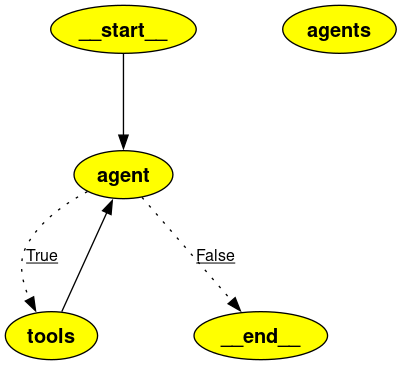

In [29]:
from IPython.display import Image

Image(agent_financeiro.graph.get_graph().draw_png())

In [ ]:
resultado_agent = agent_financeiro.invoke(
    "Quanto custa 1 bitcoint em dólares e com esse valor, converta para reais e pesos argentinos?"
)
print(resultado_agent["messages"][-1].content)

O preço atual de 1 Bitcoin é de **64642 dólares**. 

Com esse valor, as conversões são as seguintes:
- Em reais (BRL): **337.146,75**
- Em pesos argentinos (ARS): **96.644.534,85**


In [23]:
#TODO: install
!apt-get install build-essential
!apt-get install graphviz graphviz-dev
!pip install pygraphviz

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 5.4 MB/s  0:00:01m0:00:0100:01

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
